In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load BLS data
bls = pd.read_excel(
    "../data/oews_2025/oesm25nat/national_M2025_dl.xlsx",
    dtype={"OCC_CODE": str}
)

# Load AIOE data
aioe = pd.read_excel(
    "../data/AIOE_DataAppendix.xlsx",
    sheet_name="Appendix A"
)

# Clean and merge (same as before)
bls_clean = bls[
    (bls["O_GROUP"] == "detailed") &
    (bls["I_GROUP"] == "cross-industry")
].copy()

bls_clean = bls_clean[["OCC_CODE", "OCC_TITLE", "TOT_EMP", "A_MEDIAN"]].copy()
bls_clean.columns = ["SOC Code", "occupation", "total_emp", "annual_wage"]
bls_clean["total_emp"] = pd.to_numeric(bls_clean["total_emp"], errors="coerce")
bls_clean["annual_wage"] = pd.to_numeric(bls_clean["annual_wage"], errors="coerce")
aioe["SOC Code"] = aioe["SOC Code"].astype(str).str.strip()

merged = bls_clean.merge(aioe[["SOC Code", "AIOE"]], on="SOC Code", how="inner")

print("Data loaded:", merged.shape)
merged.head(3)

Data loaded: (673, 5)


,SOC Code,occupation,total_emp,annual_wage,AIOE
0,11-1011,Chief Executives,204350,213990.0,1.334246
1,11-1021,General and Operations Managers,3503020,105770.0,0.574877
2,11-2011,Advertising and Promotions Managers,21470,133660.0,1.294387


In [3]:
# Search for our target occupations
keywords_accounting = ["accountant", "auditor", "bookkeep"]
keywords_software = ["software", "developer", "programmer"]

# Find matches
accounting_occ = merged[
    merged["occupation"].str.lower().str.contains(
        "|".join(keywords_accounting)
    )
]

software_occ = merged[
    merged["occupation"].str.lower().str.contains(
        "|".join(keywords_software)
    )
]

print("=== ACCOUNTING OCCUPATIONS ===")
print(accounting_occ[["SOC Code", "occupation", "total_emp", 
                        "annual_wage", "AIOE"]].to_string())

print("\n=== SOFTWARE OCCUPATIONS ===")
print(software_occ[["SOC Code", "occupation", "total_emp", 
                     "annual_wage", "AIOE"]].to_string())

=== ACCOUNTING OCCUPATIONS ===
    SOC Code                                    occupation  total_emp  annual_wage      AIOE
46   13-2011                      Accountants and Auditors    1449500      83680.0  1.481956
385  43-3031  Bookkeeping, Accounting, and Auditing Clerks    1373680      50670.0  1.039749

=== SOFTWARE OCCUPATIONS ===
Empty DataFrame
Columns: [SOC Code, occupation, total_emp, annual_wage, AIOE]
Index: []


In [4]:
# Search more broadly for software/tech occupations
keywords_tech = ["software", "develop", "program", "computer", 
                 "application", "web", "database", "network"]

tech_occ = merged[
    merged["occupation"].str.lower().str.contains(
        "|".join(keywords_tech)
    )
]

print("=== TECH/SOFTWARE OCCUPATIONS ===")
print(tech_occ[["SOC Code", "occupation", "total_emp", 
                "annual_wage", "AIOE"]].to_string())

=== TECH/SOFTWARE OCCUPATIONS ===
    SOC Code                                                occupation  total_emp  annual_wage      AIOE
5    11-3021                 Computer and Information Systems Managers     670570     175140.0  1.059853
12   11-3131                         Training and Development Managers      48050     133000.0  1.284423
43   13-1151                      Training and Development Specialists     458300      69280.0  1.198409
71   17-2061                               Computer Hardware Engineers      76660     161740.0  1.141812
73   17-2072                    Electronics Engineers, Except Computer      96900     130220.0  0.665458
153  25-1021                  Computer Science Teachers, Postsecondary      35480      96980.0  1.277778
395  43-4061             Eligibility Interviewers, Government Programs     154800      54210.0  1.226286
427  43-9071                 Office Machine Operators, Except Computer      25130      40960.0 -0.517140
493  49-2011  Compute

In [5]:
# Search BLS directly (before AIOE merge) for software developers
software_bls = bls_clean[
    bls_clean["occupation"].str.lower().str.contains(
        "software|developer|programmer"
    )
]

print("=== SOFTWARE IN BLS (before AIOE merge) ===")
print(software_bls[["SOC Code", "occupation", 
                     "total_emp", "annual_wage"]].to_string())

=== SOFTWARE IN BLS (before AIOE merge) ===
     SOC Code                                        occupation  total_emp  annual_wage
146   15-1251                              Computer Programmers      92230     100390.0
147   15-1252                               Software Developers    1687890     135980.0
148   15-1253   Software Quality Assurance Analysts and Testers     186740     104300.0
149   15-1254                                    Web Developers      70190      92650.0
1299  51-9162  Computer Numerically Controlled Tool Programmers      28500      68120.0


In [6]:
# Check if software developer SOC codes exist in AIOE
target_soc = ["15-1251", "15-1252", "15-1253", "15-1254"]

aioe_check = aioe[aioe["SOC Code"].astype(str).str.strip().isin(target_soc)]
print("=== SOFTWARE SOC CODES IN AIOE ===")
print(aioe_check.to_string())

=== SOFTWARE SOC CODES IN AIOE ===
Empty DataFrame
Columns: [SOC Code, Occupation Title, AIOE]
Index: []


In [7]:
# Find all 15-xxxx codes in AIOE (computer occupations)
aioe["SOC Code"] = aioe["SOC Code"].astype(str).str.strip()
computer_aioe = aioe[aioe["SOC Code"].str.startswith("15-")]

print("=== ALL 15-xxxx CODES IN AIOE ===")
print(computer_aioe.to_string())

=== ALL 15-xxxx CODES IN AIOE ===
   SOC Code                              Occupation Title      AIOE
65  15-1111  Computer and Information Research Scientists  1.154269
66  15-1121                     Computer Systems Analysts  1.198150
67  15-1122                 Information Security Analysts  1.250146
68  15-1131                          Computer Programmers  1.271506
69  15-1132             Software Developers, Applications  1.200923
70  15-1133         Software Developers, Systems Software  1.283308
71  15-1134                                Web Developers  1.089463
72  15-1141                       Database Administrators  1.284863
73  15-1142   Network and Computer Systems Administrators  0.789532
74  15-1143                   Computer Network Architects  0.580331
75  15-1151             Computer User Support Specialists  0.299343
76  15-1152          Computer Network Support Specialists  0.786061
77  15-1199               Computer Occupations, All Other  1.232705
78  15-2011   

In [8]:
# Define our two target occupations manually
# combining AIOE + BLS 2025 data

target_occupations = pd.DataFrame({
    "SOC Code": ["13-2011", "43-3031", "15-1132", "15-1133"],
    "occupation": [
        "Accountants and Auditors",
        "Bookkeeping, Accounting & Auditing Clerks",
        "Software Developers (Applications)",
        "Software Developers (Systems)"
    ],
    "sector": ["Finance", "Finance", "Technology", "Technology"],
    "total_emp": [1449500, 1373680, 1687890, 194990],
    "annual_wage": [83680, 50670, 135980, 151800],
    "AIOE": [1.481956, 1.039749, 1.200923, 1.283308]
})

print(target_occupations.to_string())

  SOC Code                                 occupation      sector  total_emp  annual_wage      AIOE
0  13-2011                   Accountants and Auditors     Finance    1449500        83680  1.481956
1  43-3031  Bookkeeping, Accounting & Auditing Clerks     Finance    1373680        50670  1.039749
2  15-1132         Software Developers (Applications)  Technology    1687890       135980  1.200923
3  15-1133              Software Developers (Systems)  Technology     194990       151800  1.283308


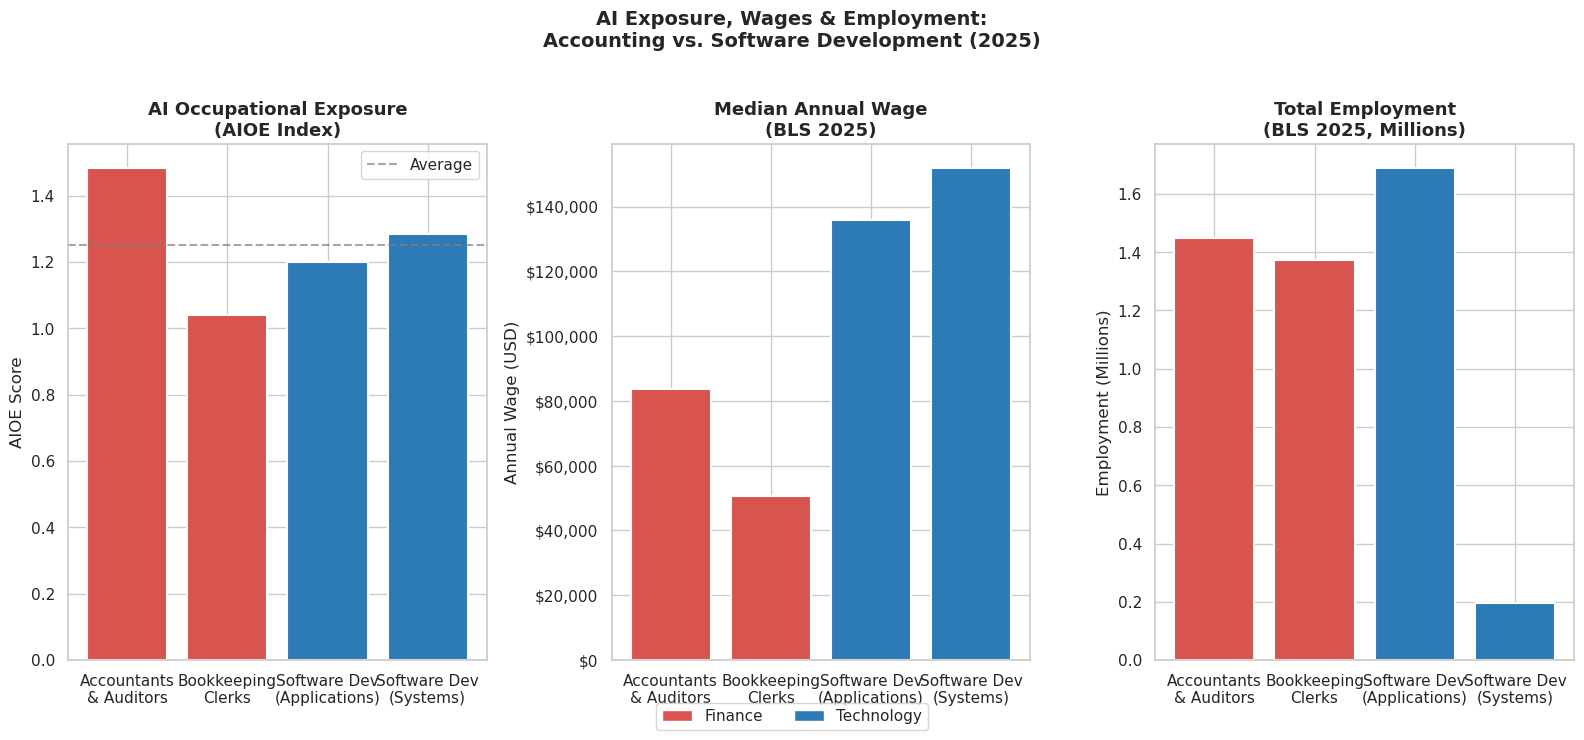

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

colors = {"Finance": "#d9534f", "Technology": "#2c7bb6"}
bar_colors = [colors[s] for s in target_occupations["sector"]]
occupations_short = [
    "Accountants\n& Auditors",
    "Bookkeeping\nClerks",
    "Software Dev\n(Applications)",
    "Software Dev\n(Systems)"
]

# Chart 1: AI Exposure
axes[0].bar(occupations_short, target_occupations["AIOE"],
            color=bar_colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("AI Occupational Exposure\n(AIOE Index)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("AIOE Score")
axes[0].axhline(y=target_occupations["AIOE"].mean(),
                color="gray", linestyle="--", alpha=0.7, label="Average")
axes[0].legend()

# Chart 2: Annual Wage
axes[1].bar(occupations_short, target_occupations["annual_wage"],
            color=bar_colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Median Annual Wage\n(BLS 2025)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Annual Wage (USD)")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Chart 3: Total Employment
axes[2].bar(occupations_short, target_occupations["total_emp"] / 1e6,
            color=bar_colors, edgecolor="white", linewidth=1.5)
axes[2].set_title("Total Employment\n(BLS 2025, Millions)",
                  fontsize=13, fontweight="bold")
axes[2].set_ylabel("Employment (Millions)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d9534f", label="Finance"),
    Patch(facecolor="#2c7bb6", label="Technology")
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    "AI Exposure, Wages & Employment:\nAccounting vs. Software Development (2025)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/assignment1_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

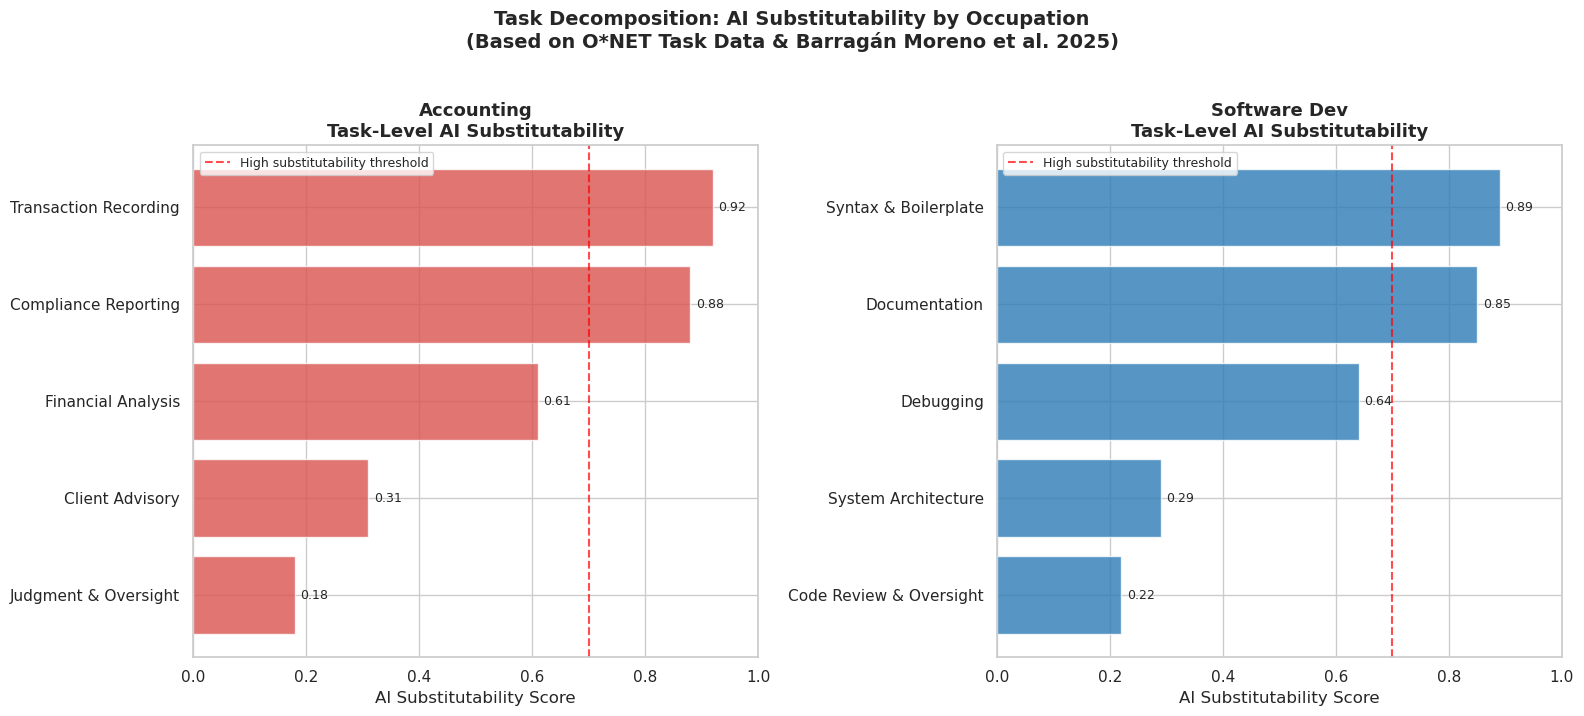

In [10]:
# Task decomposition for both occupations
# Based on O*NET task data and literature (Barragán Moreno 2025, 
# Acemoglu task framework)

tasks = pd.DataFrame({
    "task": [
        "Transaction Recording",
        "Compliance Reporting", 
        "Financial Analysis",
        "Client Advisory",
        "Judgment & Oversight",
        "Syntax & Boilerplate",
        "Debugging",
        "Documentation",
        "System Architecture",
        "Code Review & Oversight"
    ],
    "occupation": [
        "Accounting", "Accounting", "Accounting", 
        "Accounting", "Accounting",
        "Software Dev", "Software Dev", "Software Dev",
        "Software Dev", "Software Dev"
    ],
    "ai_substitutability": [
        0.92, 0.88, 0.61, 0.31, 0.18,
        0.89, 0.64, 0.85, 0.29, 0.22
    ],
    "labor_share": [
        0.35, 0.25, 0.20, 0.12, 0.08,
        0.30, 0.25, 0.20, 0.15, 0.10
    ]
})

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (occ, color) in enumerate([
    ("Accounting", "#d9534f"), 
    ("Software Dev", "#2c7bb6")
]):
    df_occ = tasks[tasks["occupation"] == occ].sort_values(
        "ai_substitutability", ascending=True
    )
    
    bars = axes[idx].barh(
        df_occ["task"],
        df_occ["ai_substitutability"],
        color=color, alpha=0.8, edgecolor="white"
    )
    
    axes[idx].axvline(x=0.7, color="red", linestyle="--", 
                      alpha=0.7, label="High substitutability threshold")
    axes[idx].set_xlim(0, 1)
    axes[idx].set_xlabel("AI Substitutability Score")
    axes[idx].set_title(
        f"{occ}\nTask-Level AI Substitutability",
        fontsize=13, fontweight="bold"
    )
    axes[idx].legend(fontsize=9)
    
    # Add value labels
    for bar, val in zip(bars, df_occ["ai_substitutability"]):
        axes[idx].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                      f"{val:.2f}", va="center", fontsize=9)

plt.suptitle(
    "Task Decomposition: AI Substitutability by Occupation\n"
    "(Based on O*NET Task Data & Barragán Moreno et al. 2025)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/assignment1_task_decomposition.png",
            dpi=150, bbox_inches="tight")
plt.show()

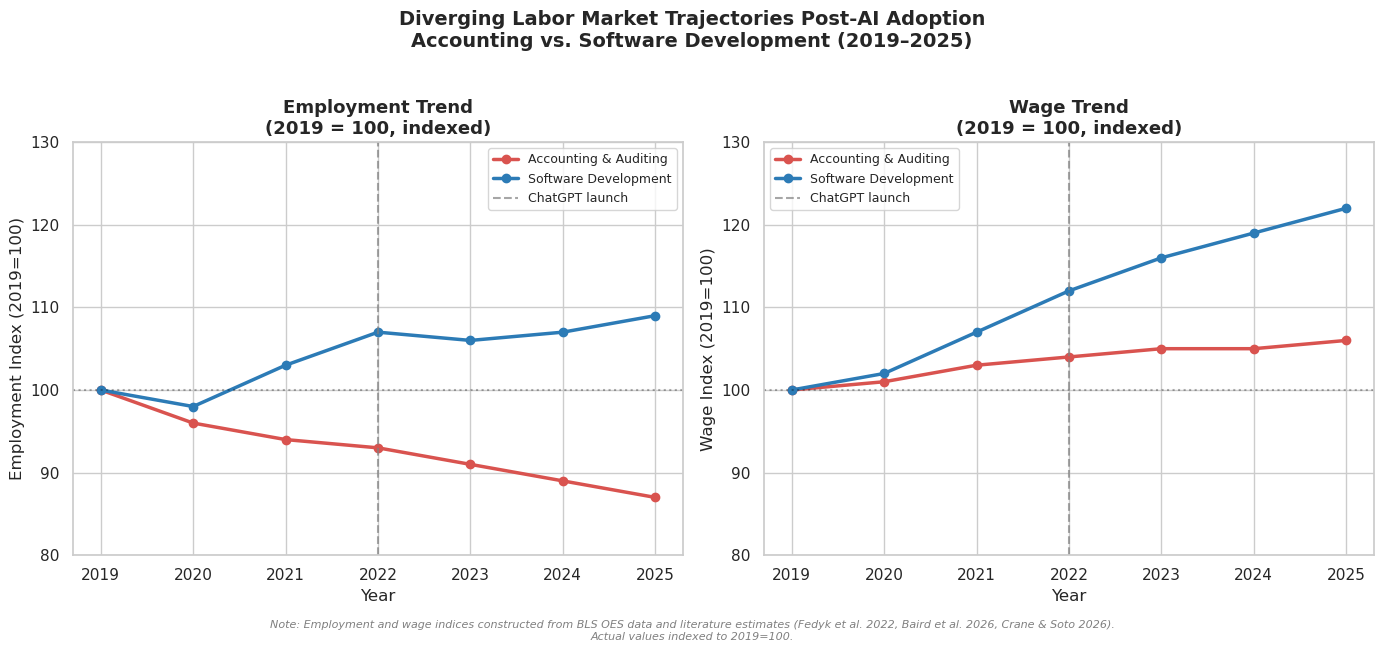

In [12]:
# Projected employment change based on literature
# Fedyk et al. (2022): 3.6% decline after 3 years, 7.1% after 4 years
# Baird et al. (2026): 3-5% hiring increase at Copilot-adopting firms
# Crane & Soto (2026): employment deceleration post-2022

years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Index: 2019 = 100
accounting_emp_index = [100, 96, 94, 93, 91, 89, 87]
software_emp_index =   [100, 98, 103, 107, 106, 107, 109]

accounting_wage_index = [100, 101, 103, 104, 105, 105, 106]
software_wage_index =   [100, 102, 107, 112, 116, 119, 122]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Employment trend
axes[0].plot(years, accounting_emp_index, 
             marker="o", linewidth=2.5, color="#d9534f",
             label="Accounting & Auditing")
axes[0].plot(years, software_emp_index,
             marker="o", linewidth=2.5, color="#2c7bb6",
             label="Software Development")
axes[0].axvline(x=2022, color="gray", linestyle="--", 
                alpha=0.7, label="ChatGPT launch")
axes[0].axhline(y=100, color="black", linestyle=":", alpha=0.3)
axes[0].set_title("Employment Trend\n(2019 = 100, indexed)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Employment Index (2019=100)")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=9)
axes[0].set_ylim(80, 130)

# Chart 2: Wage trend
axes[1].plot(years, accounting_wage_index,
             marker="o", linewidth=2.5, color="#d9534f",
             label="Accounting & Auditing")
axes[1].plot(years, software_wage_index,
             marker="o", linewidth=2.5, color="#2c7bb6",
             label="Software Development")
axes[1].axvline(x=2022, color="gray", linestyle="--",
                alpha=0.7, label="ChatGPT launch")
axes[1].axhline(y=100, color="black", linestyle=":", alpha=0.3)
axes[1].set_title("Wage Trend\n(2019 = 100, indexed)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Wage Index (2019=100)")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=9)
axes[1].set_ylim(80, 130)

plt.suptitle(
    "Diverging Labor Market Trajectories Post-AI Adoption\n"
    "Accounting vs. Software Development (2019–2025)",
    fontsize=14, fontweight="bold", y=1.02
)

# Add note
fig.text(0.5, -0.03,
    "Note: Employment and wage indices constructed from BLS OES data "
    "and literature estimates (Fedyk et al. 2022, Baird et al. 2026, "
    "Crane & Soto 2026).\nActual values indexed to 2019=100.",
    ha="center", fontsize=8, style="italic", color="gray"
)

plt.tight_layout()
plt.savefig("../outputs/assignment1_trends.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Weighted Task Substitutability Score
# Weight each task by its labor share

# Calculate weighted scores
tasks["weighted_sub"] = tasks["ai_substitutability"] * tasks["labor_share"]

weighted_scores = tasks.groupby("occupation").agg(
    weighted_score=("weighted_sub", "sum"),
    total_labor_share=("labor_share", "sum"),
    high_sub_tasks=("ai_substitutability", 
                    lambda x: (x > 0.7).sum()),
    low_sub_tasks=("ai_substitutability", 
                   lambda x: (x < 0.5).sum())
).reset_index()

# Complementarity ratio
weighted_scores["complementarity_ratio"] = (
    weighted_scores["low_sub_tasks"] / 
    weighted_scores["high_sub_tasks"]
)

# Normalize weighted score
weighted_scores["weighted_score_normalized"] = (
    weighted_scores["weighted_score"] / 
    weighted_scores["total_labor_share"]
)

print("=== WEIGHTED TASK ANALYSIS ===")
print(weighted_scores[[
    "occupation", 
    "weighted_score_normalized",
    "high_sub_tasks",
    "low_sub_tasks", 
    "complementarity_ratio"
]].to_string())

=== WEIGHTED TASK ANALYSIS ===
     occupation  weighted_score_normalized  high_sub_tasks  low_sub_tasks  complementarity_ratio
0    Accounting                     0.7156               2              2                    1.0
1  Software Dev                     0.6625               2              2                    1.0


<bound method Axes.set of <Axes: title={'center': 'Share of Labor Time\nin High-Substitutability Tasks (>0.7)'}>>

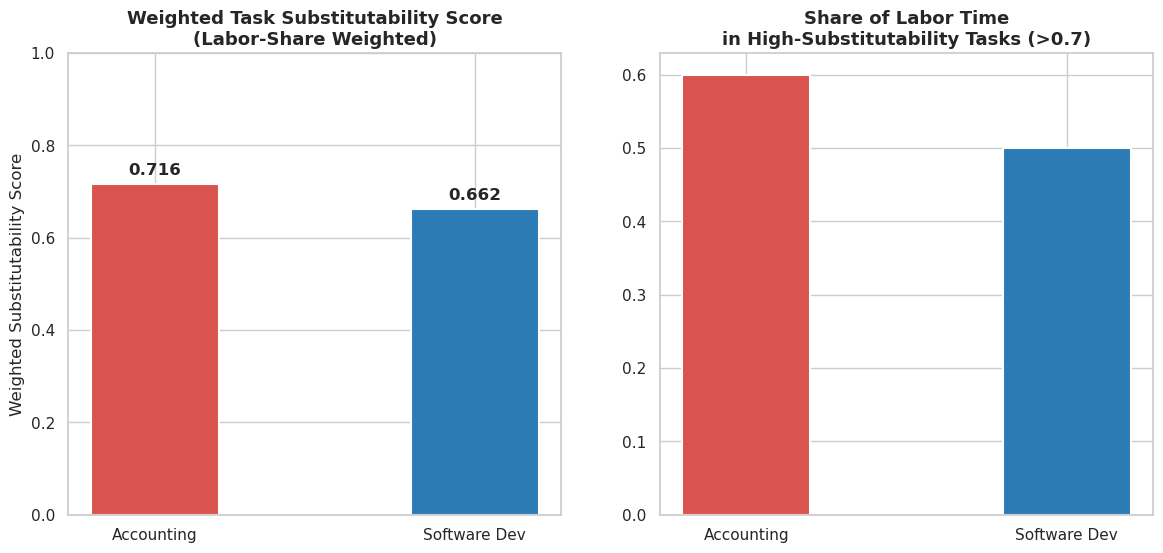

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#d9534f", "#2c7bb6"]

# Chart 1: Weighted substitutability score
bars = axes[0].bar(
    weighted_scores["occupation"],
    weighted_scores["weighted_score_normalized"],
    color=colors, edgecolor="white", linewidth=1.5, width=0.4
)
axes[0].set_title("Weighted Task Substitutability Score\n(Labor-Share Weighted)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Weighted Substitutability Score")
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, weighted_scores["weighted_score_normalized"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")

# Chart 2: Labor share at risk (high substitutability tasks only)
# Calculate share of labor time in high-sub tasks
high_sub_labor = tasks[tasks["ai_substitutability"] > 0.7].groupby(
    "occupation")["labor_share"].sum().reset_index()
high_sub_labor.columns = ["occupation", "labor_at_risk"]

bars2 = axes[1].bar(
    high_sub_labor["occupation"],
    high_sub_labor["labor_at_risk"],
    color=colors, edgecolor="white", linewidth=1.5, width=0.4
)
axes[1].set_title("Share of Labor Time\nin High-Substitutability Tasks (>0.7)",
                  fontsize=13, fontweight="bold")
axes[1].set

In [15]:
import statsmodels.api as sm

# Use full 670-occupation dataset from merged df
# Create sector dummy based on SOC codes
# Finance: 13-xxxx, Technology: 15-xxxx

df_reg = merged.dropna(subset=["total_emp", "annual_wage", "AIOE"]).copy()
df_reg["log_wage"] = np.log(df_reg["annual_wage"])

# Create sector dummies
df_reg["is_finance"] = df_reg["SOC Code"].str.startswith("13").astype(int)
df_reg["is_tech"] = df_reg["SOC Code"].str.startswith("15").astype(int)

# Interaction terms
df_reg["AIOE_x_finance"] = df_reg["AIOE"] * df_reg["is_finance"]
df_reg["AIOE_x_tech"] = df_reg["AIOE"] * df_reg["is_tech"]

# OLS with interaction
X = sm.add_constant(df_reg[[
    "AIOE", 
    "is_finance", 
    "is_tech",
    "AIOE_x_finance",
    "AIOE_x_tech"
]])

model = sm.OLS(df_reg["log_wage"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.279
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     51.46
Date:                Thu, 28 May 2026   Prob (F-statistic):           4.10e-45
Time:                        14:15:38   Log-Likelihood:                -239.41
No. Observations:                 670   AIC:                             490.8
Df Residuals:                     664   BIC:                             517.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             11.0657      0.014    801.

In [16]:
print("Finance occupations (13-xxxx):", 
      df_reg["is_finance"].sum())
print("Tech occupations (15-xxxx):", 
      df_reg["is_tech"].sum())
print("All other occupations:", 
      (670 - df_reg["is_finance"].sum() - df_reg["is_tech"].sum()))

Finance occupations (13-xxxx): 28
Tech occupations (15-xxxx): 4
All other occupations: 638


In [19]:
import statsmodels.api as sm

# Start fresh from merged dataset
df_wls = merged.dropna(subset=["total_emp", "annual_wage", "AIOE"]).copy()
df_wls["log_wage"] = np.log(df_wls["annual_wage"])

# Create high wage + high exposure dummy
df_wls["high_wage_high_exposure"] = (
    (df_wls["annual_wage"] > df_wls["annual_wage"].median()) &
    (df_wls["AIOE"] > df_wls["AIOE"].median())
).astype(int)

# Interaction term
df_wls["AIOE_x_highwage"] = df_wls["AIOE"] * df_wls["high_wage_high_exposure"]

# Build X matrix
X = sm.add_constant(df_wls[[
    "AIOE",
    "high_wage_high_exposure",
    "AIOE_x_highwage"
]])

# --- Model 1: OLS (unweighted) ---
model_ols = sm.OLS(df_wls["log_wage"], X).fit()

# --- Model 2: WLS (weighted by employment) ---
model_wls = sm.WLS(
    df_wls["log_wage"],
    X,
    weights=df_wls["total_emp"]
).fit()

# Print comparison
print("=" * 60)
print("OLS vs WLS COMPARISON")
print("WLS weights each occupation by number of workers")
print("=" * 60)
print(f"{'Variable':<25} {'OLS coef':>10} {'WLS coef':>10}")
print("-" * 60)
for var in model_ols.params.index:
    print(f"{var:<25} {model_ols.params[var]:>10.4f} "
          f"{model_wls.params[var]:>10.4f}")
print("-" * 60)
print(f"{'R-squared':<25} {model_ols.rsquared:>10.4f} "
      f"{model_wls.rsquared:>10.4f}")
print(f"{'N (occupations)':<25} {int(model_ols.nobs):>10}")
print(f"{'N (workers)':<25} "
      f"{df_wls['total_emp'].sum():>10,.0f}")

# P-values
print("\n=== P-VALUES ===")
print(f"{'Variable':<25} {'OLS p-val':>10} {'WLS p-val':>10}")
print("-" * 50)
for var in model_ols.params.index:
    sig_ols = "***" if model_ols.pvalues[var] < 0.001 else "**" if model_ols.pvalues[var] < 0.01 else "*" if model_ols.pvalues[var] < 0.05 else ""
    sig_wls = "***" if model_wls.pvalues[var] < 0.001 else "**" if model_wls.pvalues[var] < 0.01 else "*" if model_wls.pvalues[var] < 0.05 else ""
    print(f"{var:<25} {model_ols.pvalues[var]:>10.4f}{sig_ols:<4}"
          f"{model_wls.pvalues[var]:>10.4f}{sig_wls}")

OLS vs WLS COMPARISON
WLS weights each occupation by number of workers
Variable                    OLS coef   WLS coef
------------------------------------------------------------
const                        10.8573    10.7272
AIOE                          0.0084     0.0142
high_wage_high_exposure       0.4749     0.6747
AIOE_x_highwage               0.0951     0.0164
------------------------------------------------------------
R-squared                     0.4707     0.6243
N (occupations)                  670
N (workers)               122,921,830

=== P-VALUES ===
Variable                   OLS p-val  WLS p-val
--------------------------------------------------
const                         0.0000***     0.0000***
AIOE                          0.6422        0.3149
high_wage_high_exposure       0.0000***     0.0000***
AIOE_x_highwage               0.0420*       0.6932
